# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashritha-boop/fly_machine/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The queue below is a **review order**, not a forecast of what an edit will achieve. The repository ranks rows with `final_refresh_score = 70% × model probability + 30% × normalized baseline score`; the `suggested_action` and `final_reason_codes` come from the existing pipeline rules. The model was selected by held-out-client Precision@50; the ranker is a triage aid, and a reason code is a traceable signal, not an instruction to publish.

Operational archetypes here are **rule-based summaries of reason-code patterns**, not clusters or semantic labels. They make it easier to route a review while preserving the pipeline's original rank and action. The code below reports the current validation receipt, action mix, archetype-to-action map, and a small identifier-free queue preview.

In [1]:
from pathlib import Path
import importlib.util
import json
import subprocess
import sys

import pandas as pd

REPO_URL = "https://github.com/Ashritha-boop/fly_machine.git"


def find_repo_root():
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "scripts" / "run_all.py").exists() and (
            candidate / "data" / "raw" / "content_refresh_anonymized.csv"
        ).exists():
            return candidate

    if importlib.util.find_spec("google.colab") is not None:
        repo_dir = Path("/content/fly_machine")
        if not repo_dir.exists():
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_dir)], check=True)
        return repo_dir

    raise FileNotFoundError(
        "Could not locate the cloned fly_machine repo. Run this notebook from the repo or in Colab."
    )


ROOT = find_repo_root()
WORK_OUTPUTS = ROOT / "work" / "outputs"
WORK_FIGURES = ROOT / "work" / "figures"
PIPELINE_STEPS = [
    "01_prepare_features.py",
    "02_baseline_score.py",
    "03_train_model.py",
    "04_evaluate_and_export.py",
]

# The queue and metrics are regenerated from the bundled anonymized slice on each run.
for script_name in PIPELINE_STEPS:
    subprocess.run(
        [sys.executable, str(ROOT / "scripts" / script_name)],
        cwd=ROOT,
        check=True,
    )

QUEUE_SOURCE = ROOT / "outputs" / "refresh_queue.csv"
METRICS_SOURCE = ROOT / "outputs" / "model_results.json"
queue = pd.read_csv(QUEUE_SOURCE)
model_metrics = json.loads(METRICS_SOURCE.read_text(encoding="utf-8"))
required_columns = {
    "final_rank", "final_refresh_score", "best_model_probability", "confidence",
    "suggested_action", "final_reason_codes", "is_declining_label", "impressions_90d",
    "sessions_90d", "avg_position", "content_age_days", "word_count", "trend_direction",
}
missing_columns = required_columns.difference(queue.columns)
assert not missing_columns, f"Ranked queue is missing columns: {sorted(missing_columns)}"
assert len(queue) == int(model_metrics["input_rows"])
assert queue["final_rank"].tolist() == list(range(1, len(queue) + 1))
assert queue["final_refresh_score"].is_monotonic_decreasing


def classify_archetype(row):
    reasons = set(str(row["final_reason_codes"]).split("|"))
    if "thin_visible_page" in reasons:
        return "thin_visible_content"
    if "ctr_review_candidate" in reasons or "low_ctr_visible_page" in reasons:
        return "visible_low_ctr"
    if "engagement_review_candidate" in reasons or "low_engagement_visible_page" in reasons:
        return "engagement_friction"
    if "declining_with_demand" in reasons or "page_one_decay_risk" in reasons:
        return "visible_decline_risk"
    if row["suggested_action"] == "monitor":
        return "monitor_or_protect"
    return "other_refresh_review"


queue["review_archetype"] = queue.apply(classify_archetype, axis=1)
ARCHETYPE_ACTIONS = {
    "visible_decline_risk": "Refresh candidate; confirm the decline and current intent before editing.",
    "visible_low_ctr": "Review title/snippet and search intent; do not auto-rewrite metadata.",
    "engagement_friction": "Review content promise, readability, and page experience before changing copy.",
    "thin_visible_content": "Check completeness and intent; expand only when a real information gap exists.",
    "monitor_or_protect": "Monitor or protect; avoid a refresh without a specific editorial reason.",
    "other_refresh_review": "Use the pipeline action as a review prompt; inspect the listed reasons.",
}

best_name = model_metrics["best_model"]["name"]
best_metrics = model_metrics["models"][best_name]
baseline_metrics = model_metrics["baseline"]
print(f"Rows ranked: {len(queue):,} | model: {best_name} | split: {model_metrics['split_strategy']}")
print(f"Target proxy: {model_metrics['target']} | client-holdout test rows: {model_metrics['test_rows']:,}")
print(
    "Held-out Precision@20/50/100: "
    f"{best_metrics['precision_at_20']:.3f} / {best_metrics['precision_at_50']:.3f} / "
    f"{best_metrics['precision_at_100']:.3f}"
)
print(
    f"Baseline Precision@50: {baseline_metrics['baseline_precision_at_50']:.3f} | "
    f"held-out base rate: {model_metrics['target_positive_rate']:.3f}"
)
print("\nSuggested-action counts:")
display(queue["suggested_action"].value_counts().rename("rows").to_frame())
print("\nOperational archetype to action map:")
archetype_counts = queue["review_archetype"].value_counts().rename("rows").to_frame()
archetype_counts["human_review_action"] = [ARCHETYPE_ACTIONS[name] for name in archetype_counts.index]
display(archetype_counts)
print("\nFirst 12 ranked rows (identifiers omitted):")
display(
    queue[[
        "final_rank", "final_refresh_score", "confidence", "review_archetype",
        "suggested_action", "final_reason_codes", "impressions_90d", "trend_direction",
    ]].head(12)
)

Rows ranked: 30,000 | model: random_forest | split: client_holdout
Target proxy: is_declining_label | client-holdout test rows: 2,325
Held-out Precision@20/50/100: 0.650 / 0.740 / 0.720
Baseline Precision@50: 0.240 | held-out base rate: 0.542

Suggested-action counts:


,rows
suggested_action,
monitor,13083
refresh,8188
refresh_and_review_ctr,6654
refresh_and_review_engagement,1993
expand_and_refresh,82



Operational archetype to action map:


,rows,human_review_action
review_archetype,,
visible_low_ctr,9741,Review title/snippet and search intent; do not...
monitor_or_protect,7708,Monitor or protect; avoid a refresh without a ...
visible_decline_risk,7644,Refresh candidate; confirm the decline and cur...
engagement_friction,3415,"Review content promise, readability, and page ..."
other_refresh_review,1410,Use the pipeline action as a review prompt; in...
thin_visible_content,82,Check completeness and intent; expand only whe...



First 12 ranked rows (identifiers omitted):


,final_rank,final_refresh_score,confidence,review_archetype,suggested_action,final_reason_codes,impressions_90d,trend_direction
0,1,81.734212,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,12834,down
1,2,81.603243,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,2498,down
2,3,81.544618,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,8064,down
3,4,81.169731,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,13790,down
4,5,80.957565,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,3393,down
5,6,80.798090,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,5811,down
6,7,80.650656,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1622,down
7,8,80.432641,medium,visible_decline_risk,refresh,declining_with_demand|model_decline_risk|visib...,4366,down
8,9,80.428403,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1597,down
9,10,80.428243,medium,visible_decline_risk,refresh,declining_with_demand|model_decline_risk|visib...,3867,down


## 2. Intended use and limits

**Intended user:** an editor or content analyst planning a monthly review. Use the sorted queue to choose a small, capacity-bounded shortlist (start with 20); check the top rows first, then broaden only if the team has time. A rank says where to look, not which edit will work.

**Decay / refresh insight:** the bundled model's leading importance signals include days with impressions, impression volume, and average position; content age is also informative, but it is not the whole story. Treat decay as a reason to investigate when visibility, position, and/or the observed trend support it. An old page can still be valuable, and a refresh is not proven to recover traffic. Importance is a model description, not a causal effect.

**Limits:** this is a 30,000-row pseudonymized starter snapshot, one row per content item, with trailing-window metrics. `is_declining_label` is a proxy derived from the same snapshot's `trend_direction == "down"`, not a future outcome. Client-holdout metrics describe 2,325 held-out rows, but do not establish performance in a future month; the full queue is not a per-row holdout guarantee. No intervention, recovered clicks, editorial effort, calibration, live search results, or business value was measured. Do not generalize the score to other portfolios without a new validation.

In [2]:
feature_importance = pd.DataFrame(model_metrics["best_model"]["feature_importance_top"])
feature_importance = feature_importance.head(10).copy()
assert not feature_importance.empty
age_positions = feature_importance.index[feature_importance["feature"] == "content_age_days"].tolist()
print("Top model feature importances (descriptive, not causal):")
display(feature_importance)
if age_positions:
    print(
        f"content_age_days is ranked {age_positions[0] + 1} among these "
        f"{len(feature_importance)} reported features."
    )
print(
    "Refresh interpretation: combine age with visible demand, trend, position, and a human "
    "check of current intent; do not treat age or model probability as expected uplift."
)

Top model feature importances (descriptive, not causal):


,feature,importance
0,days_with_impressions,0.158144
1,log_impressions_90d,0.128638
2,avg_position,0.109164
3,content_age_days,0.095168
4,char_count,0.042608
5,word_count,0.039609
6,log_clicks_90d,0.034463
7,ctr,0.033295
8,scroll_rate,0.031226
9,days_with_sessions,0.027995


content_age_days is ranked 4 among these 10 reported features.
Refresh interpretation: combine age with visible demand, trend, position, and a human check of current intent; do not treat age or model probability as expected uplift.


## 3. Human review + the no-go list

Every row stays **pending human review**. For the first 20, an editor should verify that the metrics are current; compare the trend with seasonality and the page's own history; inspect current search intent, page/query fit, and possible cannibalization; then check factual accuracy, product availability, safety/compliance, and the cost of an edit. Record accept / defer / reject plus a short reason. Conflicting signals, missing context, or a recent major edit are reasons to pause and investigate.

**Cost/value:** use the score only to order limited review time. A 10-minute triage assumption makes a 20-row first pass about 200 minutes; deeper edits need separate effort estimates. Estimate potential value from observed demand and a documented business value per visit, then compare it with review/edit cost. The model probability is not calibrated expected recovery, and this dataset contains no causal uplift or value-per-visit evidence, so do not report ROI from it.

**Never automate:** publishing or rewriting copy; title/meta changes; deleting, pruning, redirecting, canonical/noindex changes; factual, legal, medical, or safety claims; keyword targeting or cannibalization decisions; assigning client-facing work; or budget and performance guarantees. A reviewer must own every action.

In [3]:
review_sheet = queue.head(20)[[
    "final_rank", "final_refresh_score", "confidence", "review_archetype",
    "suggested_action", "final_reason_codes", "impressions_90d", "avg_position",
    "content_age_days", "trend_direction",
]].copy()
review_sheet["review_status"] = "pending human review"
review_sheet["reviewer_note"] = ""
print("Top-20 review sheet (IDs omitted; no action is pre-approved):")
display(review_sheet)

triage_minutes_per_row_assumption = 10
first_pass_minutes = len(review_sheet) * triage_minutes_per_row_assumption
print(
    f"Capacity sketch: {len(review_sheet)} rows × {triage_minutes_per_row_assumption} assumed "
    f"triage minutes = {first_pass_minutes} minutes ({first_pass_minutes / 60:.1f} hours). "
    "This is a planning assumption, not measured editorial cost."
)
NO_GO_ACTIONS = [
    "auto-publish or auto-rewrite",
    "auto-delete, redirect, canonicalize, or noindex",
    "auto-change factual or regulated claims",
    "auto-assign client work or promise traffic recovery",
]
print("No-go automation:")
for item in NO_GO_ACTIONS:
    print(f"- {item}")

Top-20 review sheet (IDs omitted; no action is pre-approved):


,final_rank,final_refresh_score,confidence,review_archetype,suggested_action,final_reason_codes,impressions_90d,avg_position,content_age_days,trend_direction,review_status,reviewer_note
0,1,81.734212,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,12834,6.8,165,down,pending human review,
1,2,81.603243,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,2498,10.1,165,down,pending human review,
2,3,81.544618,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,8064,3.8,139,down,pending human review,
3,4,81.169731,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,13790,8.2,139,down,pending human review,
4,5,80.957565,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,3393,3.6,131,down,pending human review,
5,6,80.798090,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,5811,6.4,144,down,pending human review,
6,7,80.650656,high,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1622,3.1,139,down,pending human review,
7,8,80.432641,medium,visible_decline_risk,refresh,declining_with_demand|model_decline_risk|visib...,4366,20.1,124,down,pending human review,
8,9,80.428403,medium,visible_low_ctr,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1597,2.7,131,down,pending human review,
9,10,80.428243,medium,visible_decline_risk,refresh,declining_with_demand|model_decline_risk|visib...,3867,27.5,131,down,pending human review,


Capacity sketch: 20 rows × 10 assumed triage minutes = 200 minutes (3.3 hours). This is a planning assumption, not measured editorial cost.
No-go automation:
- auto-publish or auto-rewrite
- auto-delete, redirect, canonicalize, or noindex
- auto-change factual or regulated claims
- auto-assign client work or promise traffic recovery


## 4. Monitoring / retrain triggers

These are **proposed operating checks**, not monitored production controls. Before each monthly review, check input schema, row count, duplicates, missingness, score distribution, and action/reason mix. A schema break, a material data-coverage change, or a greater-than-20% relative shift in a major action/reason share should pause the queue for investigation; the 20% threshold is a practical starting rule, not a validated alarm.

When a later outcome window has fully matured, compare Precision@20/50/100 and the label base rate on the same client/time-aware evaluation design. Review the model if Precision@50 drops below the contemporaneous base rate, or falls at least 0.15 below this run's held-out 0.74 for two consecutive labeled checks. Investigate drift and label quality before retraining; compare any candidate with the frozen baseline, and require human sign-off before replacing the reviewed model. Do not retrain automatically or treat a calendar date alone as evidence that retraining will help.

In [4]:
monitoring_plan = pd.DataFrame([
    {
        "check": "Input contract",
        "proposed_trigger": "Schema change, duplicate content rows, or material missingness/coverage shift",
        "response": "Pause export; verify source and window before review",
    },
    {
        "check": "Queue mix",
        "proposed_trigger": ">20% relative shift in a major action/reason share vs prior run",
        "response": "Inspect data and editorial changes; do not assume model drift alone",
    },
    {
        "check": "Mature outcomes",
        "proposed_trigger": "P@50 below base rate, or >=0.15 below 0.74 for two labeled checks",
        "response": "Revalidate against frozen baseline; retrain only if evidence supports it",
    },
])
print("Proposed light monitoring policy (not yet operationalized):")
display(monitoring_plan)
print(
    f"Current reference: held-out P@50={best_metrics['precision_at_50']:.3f}; "
    f"held-out label base rate={model_metrics['target_positive_rate']:.3f}. "
    "Future checks need mature labels and the same evaluation design."
)

Proposed light monitoring policy (not yet operationalized):


,check,proposed_trigger,response
0,Input contract,"Schema change, duplicate content rows, or mate...",Pause export; verify source and window before ...
1,Queue mix,>20% relative shift in a major action/reason s...,Inspect data and editorial changes; do not ass...
2,Mature outcomes,"P@50 below base rate, or >=0.15 below 0.74 for...",Revalidate against frozen baseline; retrain on...


Current reference: held-out P@50=0.740; held-out label base rate=0.542. Future checks need mature labels and the same evaluation design.


## 5. Exports for the paper

The final cell regenerates three paper inputs under `work/`: the complete ranked queue CSV (ignored by git as required), a compact metrics JSON receipt (committed), and a reusable action-mix figure under `work/figures/` (committed). The queue preserves source scores, actions, and reason codes and adds the explicitly rule-based review archetype. The figure and receipt contain no row identifiers.

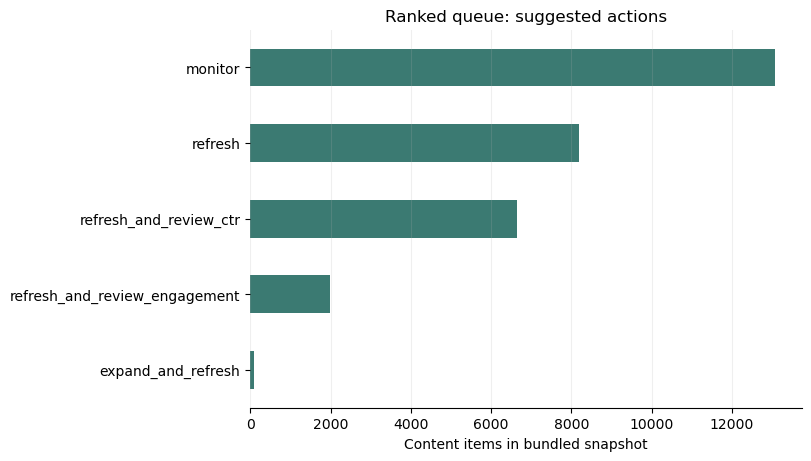

Ranked queue: C:\Users\ASHRITHA\fly_machine\work\outputs\ranked_content_action_queue.csv (30,000 rows; CSV is gitignored)
Paper metrics receipt: C:\Users\ASHRITHA\fly_machine\work\outputs\action_playbook_metrics.json
Reusable figure: C:\Users\ASHRITHA\fly_machine\work\figures\action_playbook_action_mix.png


In [5]:
import matplotlib.pyplot as plt

WORK_OUTPUTS.mkdir(parents=True, exist_ok=True)
WORK_FIGURES.mkdir(parents=True, exist_ok=True)
QUEUE_EXPORT = WORK_OUTPUTS / "ranked_content_action_queue.csv"
METRICS_EXPORT = WORK_OUTPUTS / "action_playbook_metrics.json"
FIGURE_EXPORT = WORK_FIGURES / "action_playbook_action_mix.png"

export_columns = [
    "final_rank", "content_id", "client_id", "final_refresh_score",
    "best_model_name", "best_model_probability", "baseline_refresh_score", "confidence",
    "suggested_action", "final_reason_codes", "review_archetype", "is_declining_label",
    "impressions_90d", "clicks_90d", "sessions_90d", "avg_position", "ctr",
    "content_age_days", "days_since_last_update", "word_count", "trend_direction",
    "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier",
]
queue[export_columns].to_csv(QUEUE_EXPORT, index=False)

action_counts = queue["suggested_action"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
action_counts.plot.barh(ax=ax, color="#3b7a72")
ax.set_title("Ranked queue: suggested actions")
ax.set_xlabel("Content items in bundled snapshot")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
fig.savefig(FIGURE_EXPORT, dpi=180, facecolor="white")
plt.show()
plt.close(fig)

reason_counts = {}
for reason_text in queue["final_reason_codes"].fillna(""):
    for reason in str(reason_text).split("|"):
        if reason:
            reason_counts[reason] = reason_counts.get(reason, 0) + 1

metrics_payload = {
    "source": {
        "dataset": "data/raw/content_refresh_anonymized.csv",
        "grain": "one pseudonymized content item per row",
        "rows_scored": int(len(queue)),
        "target": model_metrics["target"],
        "target_definition": "is_declining_label derived from same-snapshot trend_direction == down; not a future outcome",
    },
    "validation": {
        "split_strategy": model_metrics["split_strategy"],
        "train_rows": int(model_metrics["train_rows"]),
        "test_rows": int(model_metrics["test_rows"]),
        "test_base_rate": float(model_metrics["target_positive_rate"]),
        "selected_model": best_name,
        "selection_metric": model_metrics["best_model"]["selection_metric"],
        "precision_at_20": float(best_metrics["precision_at_20"]),
        "precision_at_50": float(best_metrics["precision_at_50"]),
        "precision_at_100": float(best_metrics["precision_at_100"]),
        "baseline_precision_at_50": float(baseline_metrics["baseline_precision_at_50"]),
        "interpretation": "held-out-client ranking metrics on the proxy label; not action uplift or future-month validation",
    },
    "rank_score": {
        "model_probability_weight": 0.70,
        "normalized_baseline_weight": 0.30,
        "use": "human review ordering only",
    },
    "suggested_action_counts": {str(key): int(value) for key, value in queue["suggested_action"].value_counts().items()},
    "review_archetype_counts": {str(key): int(value) for key, value in queue["review_archetype"].value_counts().items()},
    "reason_code_row_counts": {str(key): int(value) for key, value in sorted(reason_counts.items())},
    "exports": {
        "queue_csv": "work/outputs/ranked_content_action_queue.csv",
        "metrics_json": "work/outputs/action_playbook_metrics.json",
        "action_mix_figure": "work/figures/action_playbook_action_mix.png",
    },
    "governance": {
        "human_review_required": True,
        "automated_actions_allowed": [],
        "monitoring_thresholds_status": "proposed policy; not empirically validated",
    },
}
METRICS_EXPORT.write_text(json.dumps(metrics_payload, indent=2, allow_nan=False) + "\n", encoding="utf-8")

print(f"Ranked queue: {QUEUE_EXPORT} ({len(queue):,} rows; CSV is gitignored)")
print(f"Paper metrics receipt: {METRICS_EXPORT}")
print(f"Reusable figure: {FIGURE_EXPORT}")
assert QUEUE_EXPORT.exists() and METRICS_EXPORT.exists() and FIGURE_EXPORT.exists()
assert len(pd.read_csv(QUEUE_EXPORT)) == len(queue)
assert json.loads(METRICS_EXPORT.read_text(encoding="utf-8"))["validation"]["split_strategy"] == "client_holdout"

## 6. Self-check

- [x] All five playbook sections include decision rationale and supporting code.
- [x] Notebook executes top to bottom without errors.
- [x] Notebook outputs and exports contain no client names, content URLs, or private queries.
- [x] Claims are limited to observed, held-out proxy-label ranking and decision support; no causal or future-outcome claim is made.
- [x] Queue is regenerated at `work/outputs/ranked_content_action_queue.csv` and stays out of git; metrics receipt and paper figure are committed.
- [x] Every recommended action remains subject to human review; automation no-go cases are explicit.

Submission repo: https://github.com/Ashritha-boop/fly_machine